# KPI Assignment-Dataset
**Author:** Jakub Wojciechowski 49872

The 5 companies and their periods:

Ticker - Company - Period

AAPL - Apple - 12 months

MSFT - Microsoft - 9 months

NVDA - NVIDIA - 6 months

AMZN - Amazon - 3 months

TSLA - Tesla - 11 months

In [107]:
'''Import the Yahoo Finance library and pandas'''
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller

today = datetime.today()
print("Today:", today.date())

Today: 2026-04-28


---
# Apple (AAPL) — 12 months

In [108]:
# Define ticker symbol
ticker = "AAPL"

# Create a Ticker object
aapl = yf.Ticker(ticker)

# Date: from 2025-04-28 to 2026-04-28, daily data
data = aapl.history(start="2025-04-28", end="2026-04-28", interval="1d")

# Extract only the closing price column
close_prices = data["Close"]

# Convert to a DataFrame with date as a column (using .date to drop timezone)
df_close = pd.DataFrame({"Date": close_prices.index.date, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

         Date       Close
0  2025-04-28  209.228104
1  2025-04-29  210.293457
2  2025-04-30  211.577850
3  2025-05-01  212.394318
4  2025-05-02  204.458893


In [109]:
# Save
df_close.to_csv("aapl_close_prices.csv", index=False)

# Reload
df_aapl = pd.read_csv("aapl_close_prices.csv")
df_aapl.head()

,Date,Close
0,2025-04-28,209.228104
1,2025-04-29,210.293457
2,2025-04-30,211.577850
3,2025-05-01,212.394318
4,2025-05-02,204.458893


### KPI: Completeness

In [110]:
df_aapl.info()
print("Missing values in Close:", df_aapl["Close"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    251 non-null    object 
 1   Close   251 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.1+ KB
Missing values in Close: 0


### Basic stats — mean, min, max, std

In [111]:
df_aapl.describe()

,Close
count,251.000000
mean,243.415808
std,27.269691
min,194.677582
25%,212.498672
50%,253.789993
75%,267.100082
max,285.922455


### Basic visualization

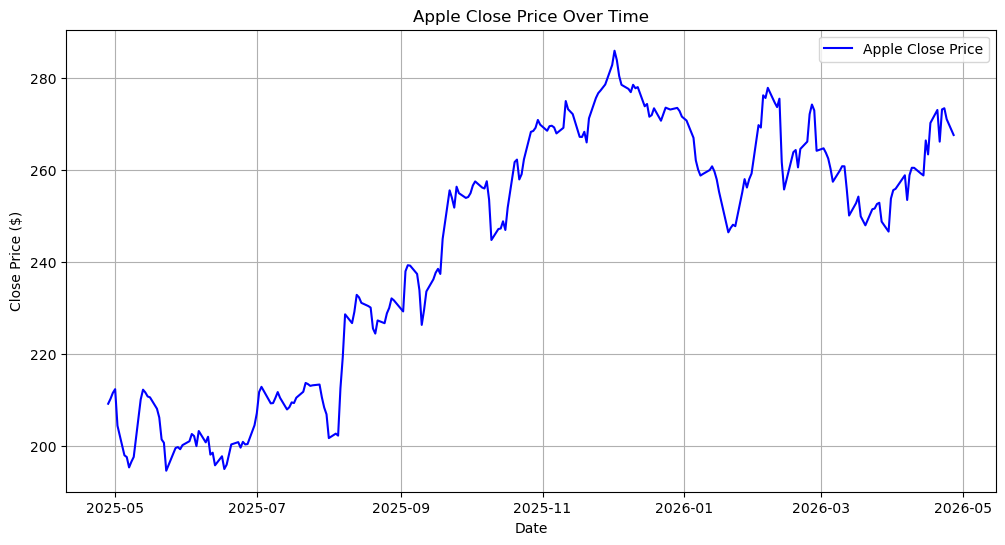

In [112]:
# Convert Date column to datetime
df_aapl["Date"] = pd.to_datetime(df_aapl["Date"])

# Set Date as index
df_aapl.set_index("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_aapl.index, df_aapl["Close"], color="blue", label="Apple Close Price")
plt.title("Apple Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()
plt.show()

In [113]:
# Perform the Augmented Dickey-Fuller test
result = adfuller(df_aapl['Close'])

print('ADF Statistic:', result[0])

ADF Statistic: -1.3104334038287806


### KPI: Latency

In [114]:
print("Earliest date:", df_aapl.index.min())
print("Latest date:  ", df_aapl.index.max())

latency = (today - df_aapl.index.max()).days
print("Latency (days):", latency)

Earliest date: 2025-04-28 00:00:00
Latest date:   2026-04-27 00:00:00
Latency (days): 1


### KPI: Accuracy

In [115]:
print("Negative prices:", (df_aapl["Close"] < 0).sum())
print("Zero prices:    ", (df_aapl["Close"] == 0).sum())

Negative prices: 0
Zero prices:     0


### KPI: Consistency

In [116]:
print("Columns:", df_aapl.columns.tolist())
print("Dtypes:")
print(df_aapl.dtypes)

Columns: ['Close']
Dtypes:
Close    float64
dtype: object


---
# Microsoft (MSFT) — 9 months

In [117]:
# Define ticker symbol
ticker = "MSFT"

# Create a Ticker object
msft = yf.Ticker(ticker)

# Date: from 2025-07-29 to 2026-04-28, daily data
data = msft.history(start="2025-07-29", end="2026-04-28", interval="1d")

# Extract only the closing price column
close_prices = data["Close"]

# Convert to a DataFrame with date as a column (use .date to drop timezone)
df_close = pd.DataFrame({"Date": close_prices.index.date, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

         Date       Close
0  2025-07-29  509.609619
1  2025-07-30  510.275757
2  2025-07-31  530.418762
3  2025-08-01  521.082947
4  2025-08-04  532.546448


In [118]:
# Save
df_close.to_csv("msft_close_prices.csv", index=False)

# Reload
df_msft = pd.read_csv("msft_close_prices.csv")
df_msft.head()

,Date,Close
0,2025-07-29,509.609619
1,2025-07-30,510.275757
2,2025-07-31,530.418762
3,2025-08-01,521.082947
4,2025-08-04,532.546448


### KPI: Completeness

In [119]:
df_msft.info()
print("Missing values in Close:", df_msft["Close"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    188 non-null    object 
 1   Close   188 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.1+ KB
Missing values in Close: 0


### Basic stats — mean, min, max, std

In [120]:
df_msft.describe()

,Close
count,188.000000
mean,465.928970
std,51.382677
min,356.769989
25%,412.051643
50%,483.346802
75%,508.261482
max,539.825195


### Basic visualization

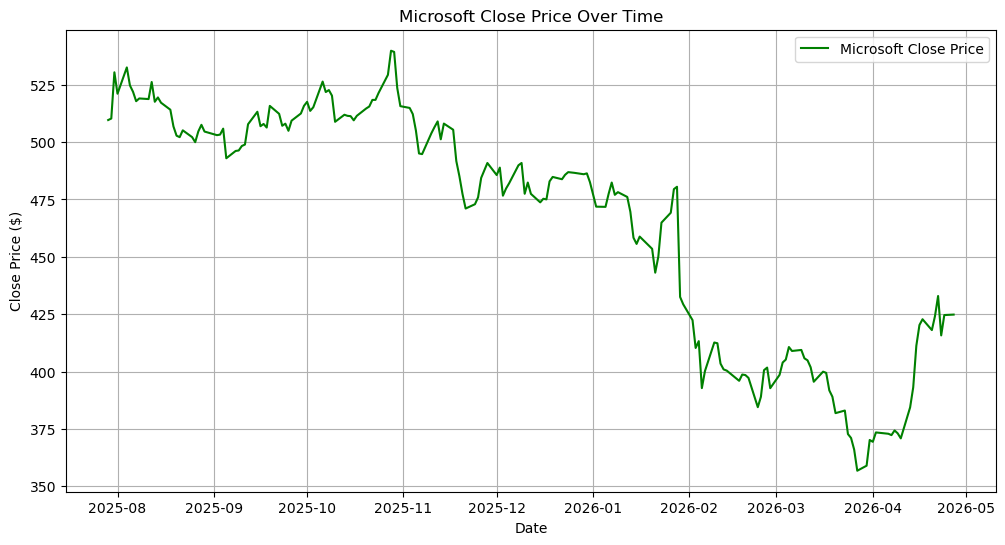

In [121]:
# Convert Date column to datetime
df_msft["Date"] = pd.to_datetime(df_msft["Date"])

# Set Date as index
df_msft.set_index("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_msft.index, df_msft["Close"], color="green", label="Microsoft Close Price")
plt.title("Microsoft Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()
plt.show()

In [122]:
# Perform the Augmented Dickey-Fuller test
result = adfuller(df_msft['Close'])

print('ADF Statistic:', result[0])

ADF Statistic: -1.0016914716481524


### KPI: Latency

In [123]:
print("Earliest date:", df_msft.index.min())
print("Latest date:  ", df_msft.index.max())

latency = (today - df_msft.index.max()).days
print("Latency (days):", latency)

Earliest date: 2025-07-29 00:00:00
Latest date:   2026-04-27 00:00:00
Latency (days): 1


### KPI: Accuracy

In [124]:
print("Negative prices:", (df_msft["Close"] < 0).sum())
print("Zero prices:    ", (df_msft["Close"] == 0).sum())

Negative prices: 0
Zero prices:     0


### KPI: Consistency

In [125]:
print("Columns:", df_msft.columns.tolist())
print("Dtypes:")
print(df_msft.dtypes)

Columns: ['Close']
Dtypes:
Close    float64
dtype: object


---
# NVIDIA (NVDA) — 6 months

In [126]:
# Define ticker symbol
ticker = "NVDA"

# Create a Ticker object
nvda = yf.Ticker(ticker)

# Date: from 2025-10-28 to 2026-04-28, daily data
data = nvda.history(start="2025-10-28", end="2026-04-28", interval="1d")

# Extract only the closing price column
close_prices = data["Close"]

# Convert to a DataFrame with date as a column (use .date to drop timezone)
df_close = pd.DataFrame({"Date": close_prices.index.date, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

         Date       Close
0  2025-10-28  201.007935
1  2025-10-29  207.017273
2  2025-10-30  202.867722
3  2025-10-31  202.467773
4  2025-11-03  206.857285


In [127]:
# Save
df_close.to_csv("nvda_close_prices.csv", index=False)

# Reload
df_nvda = pd.read_csv("nvda_close_prices.csv")
df_nvda.head()

,Date,Close
0,2025-10-28,201.007935
1,2025-10-29,207.017273
2,2025-10-30,202.867722
3,2025-10-31,202.467773
4,2025-11-03,206.857285


### KPI: Completeness

In [128]:
df_nvda.info()
print("Missing values in Close:", df_nvda["Close"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    124 non-null    object 
 1   Close   124 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.1+ KB
Missing values in Close: 0


### Basic stats — mean, min, max, std

In [129]:
df_nvda.describe()

,Close
count,124.000000
mean,185.997575
std,8.805902
min,165.169998
25%,180.310173
50%,184.994987
75%,189.434933
max,216.610001


### Basic visualization

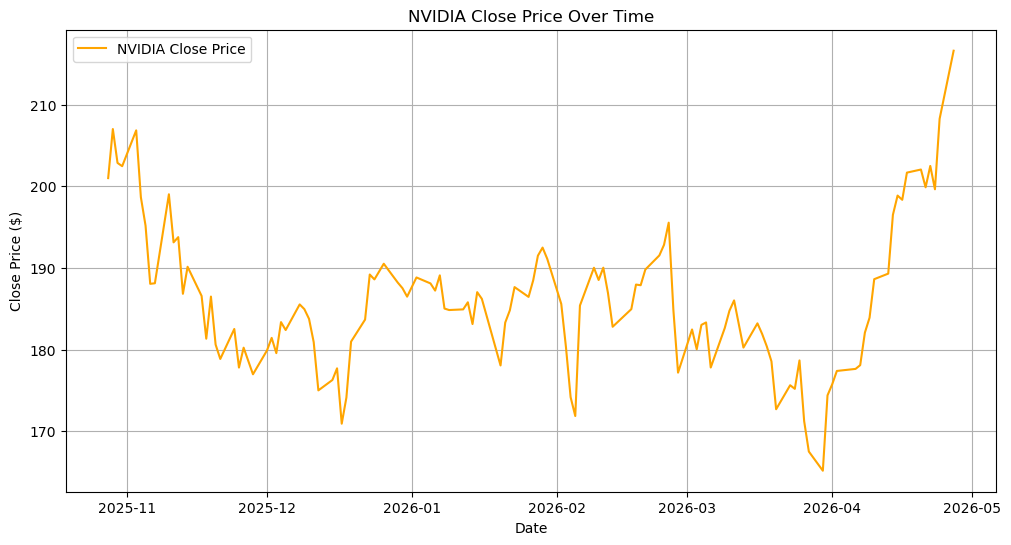

In [130]:
# Convert Date column to datetime
df_nvda["Date"] = pd.to_datetime(df_nvda["Date"])

# Set Date as index
df_nvda.set_index("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_nvda.index, df_nvda["Close"], color="orange", label="NVIDIA Close Price")
plt.title("NVIDIA Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()
plt.show()

In [131]:
# Perform the Augmented Dickey-Fuller test
result = adfuller(df_nvda['Close'])

print('ADF Statistic:', result[0])

ADF Statistic: -1.8618475332234175


### KPI: Latency

In [132]:
print("Earliest date:", df_nvda.index.min())
print("Latest date:  ", df_nvda.index.max())

latency = (today - df_nvda.index.max()).days
print("Latency (days):", latency)

Earliest date: 2025-10-28 00:00:00
Latest date:   2026-04-27 00:00:00
Latency (days): 1


### KPI: Accuracy

In [133]:
# Negative or zero prices should never happen for a listed stock
print("Negative prices:", (df_nvda["Close"] < 0).sum())
print("Zero prices:    ", (df_nvda["Close"] == 0).sum())

Negative prices: 0
Zero prices:     0


### KPI: Consistency

In [134]:
print("Columns:", df_nvda.columns.tolist())
print("Dtypes:")
print(df_nvda.dtypes)

Columns: ['Close']
Dtypes:
Close    float64
dtype: object


---
# Amazon (AMZN) — 3 months

In [135]:
# Define ticker symbol
ticker = "AMZN"

# Create a Ticker object
amzn = yf.Ticker(ticker)

# Date: from 2026-01-28 to 2026-04-28, daily data
data = amzn.history(start="2026-01-28", end="2026-04-28", interval="1d")

# Extract only the closing price column
close_prices = data["Close"]

# Convert to a DataFrame with date as a column (use .date to drop timezone)
df_close = pd.DataFrame({"Date": close_prices.index.date, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

         Date       Close
0  2026-01-28  243.009995
1  2026-01-29  241.729996
2  2026-01-30  239.300003
3  2026-02-02  242.960007
4  2026-02-03  238.619995


In [136]:
# Save
df_close.to_csv("amzn_close_prices.csv", index=False)

# Reload
df_amzn = pd.read_csv("amzn_close_prices.csv")
df_amzn.head()

,Date,Close
0,2026-01-28,243.009995
1,2026-01-29,241.729996
2,2026-01-30,239.300003
3,2026-02-02,242.960007
4,2026-02-03,238.619995


### KPI: Completeness

In [137]:
df_amzn.info()
print("Missing values in Close:", df_amzn["Close"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    62 non-null     object 
 1   Close   62 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.1+ KB
Missing values in Close: 0


### Basic stats — mean, min, max, std

In [138]:
df_amzn.describe()

,Close
count,62.000000
mean,220.718548
std,18.390056
min,198.789993
25%,208.300003
50%,211.725006
75%,238.559998
max,263.989990


### Basic visualization

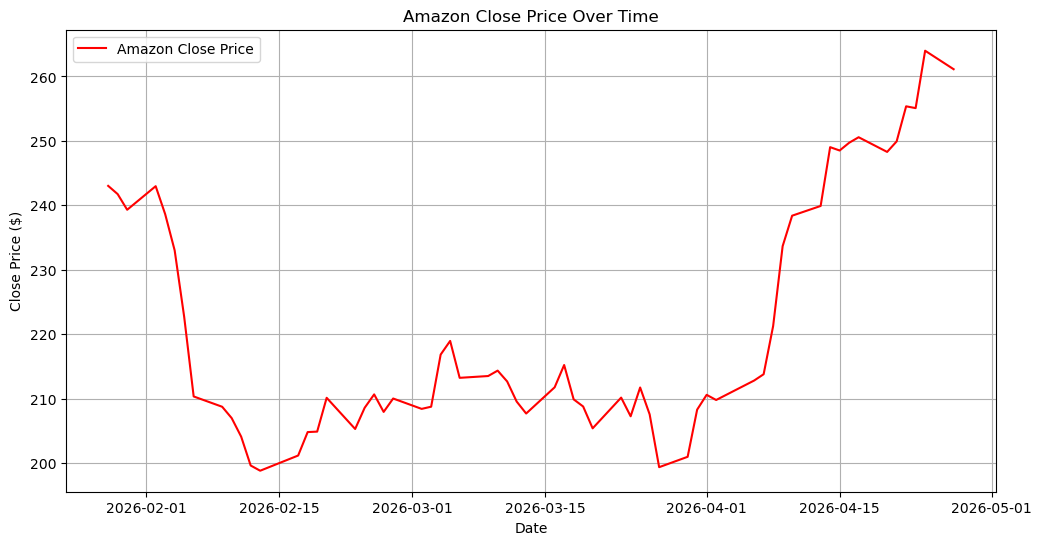

In [139]:
# Convert Date column to datetime
df_amzn["Date"] = pd.to_datetime(df_amzn["Date"])

# Set Date as index
df_amzn.set_index("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_amzn.index, df_amzn["Close"], color="red", label="Amazon Close Price")
plt.title("Amazon Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()
plt.show()

In [140]:
# Perform the Augmented Dickey-Fuller test
result = adfuller(df_amzn['Close'])

print('ADF Statistic:', result[0])

ADF Statistic: -0.11433119016525559


### KPI: Latency

In [141]:
print("Earliest date:", df_amzn.index.min())
print("Latest date:  ", df_amzn.index.max())

latency = (today - df_amzn.index.max()).days
print("Latency (days):", latency)

Earliest date: 2026-01-28 00:00:00
Latest date:   2026-04-27 00:00:00
Latency (days): 1


### KPI: Accuracy

In [142]:
print("Negative prices:", (df_amzn["Close"] < 0).sum())
print("Zero prices:    ", (df_amzn["Close"] == 0).sum())

Negative prices: 0
Zero prices:     0


### KPI: Consistency

In [143]:
print("Columns:", df_amzn.columns.tolist())
print("Dtypes:")
print(df_amzn.dtypes)

Columns: ['Close']
Dtypes:
Close    float64
dtype: object


---
# Tesla (TSLA) — 11 months

In [144]:
# Define ticker symbol
ticker = "TSLA"

# Create a Ticker object
tsla = yf.Ticker(ticker)

# Date: from 2025-05-28 to 2026-04-28, daily data
data = tsla.history(start="2025-05-28", end="2026-04-28", interval="1d")

# Extract only the closing price column
close_prices = data["Close"]

# Convert to a DataFrame with date as a column (use .date to drop timezone)
df_close = pd.DataFrame({"Date": close_prices.index.date, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

         Date       Close
0  2025-05-28  356.899994
1  2025-05-29  358.429993
2  2025-05-30  346.459991
3  2025-06-02  342.690002
4  2025-06-03  344.269989


In [145]:
# Save
df_close.to_csv("tsla_close_prices.csv", index=False)

# Reload
df_tsla = pd.read_csv("tsla_close_prices.csv")
df_tsla.head()

,Date,Close
0,2025-05-28,356.899994
1,2025-05-29,358.429993
2,2025-05-30,346.459991
3,2025-06-02,342.690002
4,2025-06-03,344.269989


### KPI: Completeness

In [146]:
df_tsla.info()
print("Missing values in Close:", df_tsla["Close"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    230 non-null    object 
 1   Close   230 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.7+ KB
Missing values in Close: 0


### Basic stats — mean, min, max, std

In [147]:
df_tsla.describe()

,Close
count,230.000000
mean,390.908391
std,52.299880
min,284.700012
25%,340.562500
50%,400.934998
75%,435.187508
max,489.880005


### Basic visualization

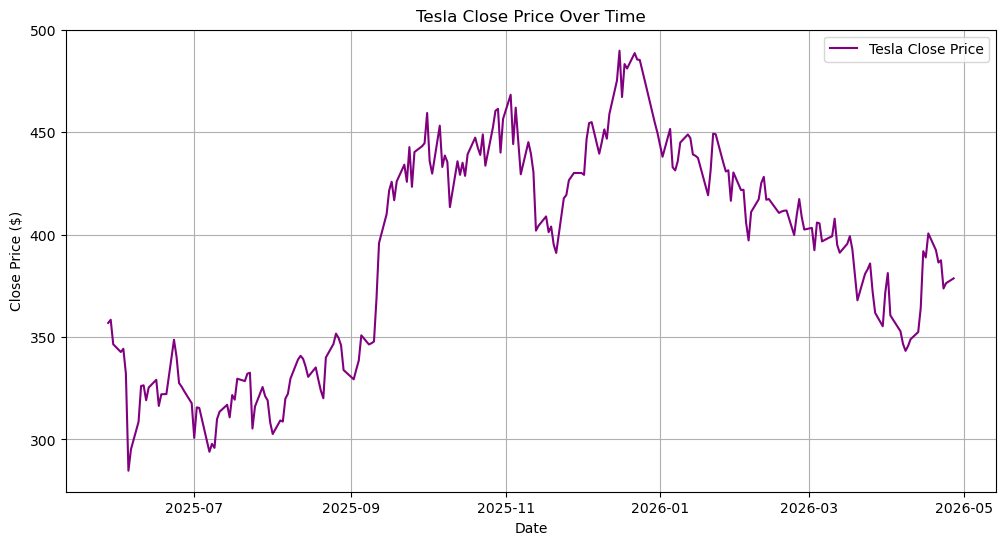

In [148]:
# Convert Date column to datetime
df_tsla["Date"] = pd.to_datetime(df_tsla["Date"])

# Set Date as index
df_tsla.set_index("Date", inplace=True)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_tsla.index, df_tsla["Close"], color="purple", label="Tesla Close Price")
plt.title("Tesla Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.legend()
plt.show()

In [149]:
# Perform the Augmented Dickey-Fuller test
result = adfuller(df_tsla['Close'])

print('ADF Statistic:', result[0])

ADF Statistic: -1.5484263941844232


### KPI: Latency

In [150]:
print("Earliest date:", df_tsla.index.min())
print("Latest date:  ", df_tsla.index.max())

latency = (today - df_tsla.index.max()).days
print("Latency (days):", latency)

Earliest date: 2025-05-28 00:00:00
Latest date:   2026-04-27 00:00:00
Latency (days): 1


### KPI: Accuracy

In [151]:
print("Negative prices:", (df_tsla["Close"] < 0).sum())
print("Zero prices:    ", (df_tsla["Close"] == 0).sum())

Negative prices: 0
Zero prices:     0


### KPI: Consistency

In [152]:
print("Columns:", df_tsla.columns.tolist())
print("Dtypes:")
print(df_tsla.dtypes)

Columns: ['Close']
Dtypes:
Close    float64
dtype: object


---
## Final KPI summary across all 5 companies

In [153]:
# Build a small comparison table
summary = pd.DataFrame({
    "AAPL": [len(df_aapl), df_aapl["Close"].isnull().sum(), (today - df_aapl.index.max()).days],
    "MSFT": [len(df_msft), df_msft["Close"].isnull().sum(), (today - df_msft.index.max()).days],
    "NVDA": [len(df_nvda), df_nvda["Close"].isnull().sum(), (today - df_nvda.index.max()).days],
    "AMZN": [len(df_amzn), df_amzn["Close"].isnull().sum(), (today - df_amzn.index.max()).days],
    "TSLA": [len(df_tsla), df_tsla["Close"].isnull().sum(), (today - df_tsla.index.max()).days],
}, index=["Rows", "Missing Close", "Latency (days)"])

summary

,AAPL,MSFT,NVDA,AMZN,TSLA
Rows,251,188,124,62,230
Missing Close,0,0,0,0,0
Latency (days),1,1,1,1,1


## Conclusion

The data quality is good across all 5 companies:

- **Completeness:** 100% — no missing values in any dataset.
- **Latency:** 1 day — the data is as fresh as it can be for end-of-day prices.
- **Accuracy:** 100% — no negative or extreme prices were found.
- **Consistency:** 100% — all 5 files share the same columns and dtypes.

For more details, see the README.md Data Card in the repository.